In [1]:
import pandas as pd

df = pd.read_csv('/content/Preprocess_Weather_data.csv')
df.sample(10)

,Timestamp,PM2.5,PM10,Carbon_Monoxide_CO,Nitrogen_Dioxide_NO2,Sulphur_Dioxide_SO2,Ozone_O3,European_AQI,Temperature,Humidity,Wind_Speed,Air_Pressure,Rainfall,PM2.5_3h_Mean,PM2.5_3h_Std,PM2.5_6h_Mean,PM2.5_6h_Std,PM2.5_24h_Mean,PM2.5_24h_Std
18413,2025-02-07 04:00:00,39.2,40.7,800.0,40.3,10.3,72.0,68,14.1,31,10.6,1019.8,0.0,38.500000,2.816026,36.283333,3.242478,35.308333,12.443889
17068,2024-12-13 03:00:00,34.5,36.6,1218.0,37.8,10.4,39.0,74,7.3,55,9.3,1022.1,0.0,30.133333,4.209909,29.233333,3.180985,41.929167,21.608160
13499,2024-07-17 10:00:00,41.1,80.3,334.0,3.8,10.2,193.0,71,35.6,46,4.3,999.3,0.0,41.200000,0.100000,41.500000,0.517687,36.950000,4.158281
17069,2024-12-13 04:00:00,37.3,38.8,1048.0,33.4,11.9,55.0,74,10.8,44,8.9,1022.5,0.0,33.866667,3.789899,30.300000,4.605649,41.512500,21.596504
12326,2024-05-29 13:00:00,12.2,21.7,367.0,19.1,5.1,140.0,62,35.6,34,1.6,995.3,0.0,12.766667,0.737111,13.100000,0.593296,12.700000,2.580361
10767,2024-03-25 14:00:00,16.5,24.9,630.0,41.9,5.8,79.0,62,21.3,46,12.2,1012.2,0.0,14.133333,2.510644,15.200000,2.003996,26.745833,11.265838
1691,2023-03-13 10:00:00,28.5,45.1,338.0,8.6,9.1,155.0,65,28.2,26,10.7,1012.7,0.0,31.266667,2.909181,34.916667,4.447659,30.629167,5.737556
22098,2025-07-10 17:00:00,68.7,80.1,1174.0,71.7,9.8,33.0,62,25.5,86,5.4,1003.7,0.0,62.833333,5.244362,58.116667,6.250573,28.904167,18.518416
7200,2023-10-28 23:00:00,12.5,17.8,896.0,33.8,1.7,6.0,60,15.5,75,7.0,1014.0,0.0,16.666667,4.361575,25.066667,10.376062,25.120833,10.218780
16068,2024-11-01 11:00:00,30.0,43.9,2142.0,65.7,9.7,66.0,47,24.3,60,6.8,1011.4,0.0,27.100000,2.685144,22.616667,5.603005,21.954167,8.303953


In [2]:
!pip install lightgbm xgboost catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.0 MB/s eta 0:00:00


In [5]:
df["AQI_24h_Forecast"] = df["European_AQI"].shift(-24)

In [6]:
df.dropna(inplace=True)

In [10]:
X = df.drop(columns=[
    'Timestamp', 'AQI_3h_Forecast', 'Month', 'Day_Type', 'Hour', 'European_AQI', 'AQI_6h_Forecast', 'AQI_12h_Forecast', 'AQI_24h_Forecast'
], errors='ignore')

y = df['AQI_24h_Forecast']

In [11]:
X.columns

Index(['PM2.5', 'PM10', 'Carbon_Monoxide_CO', 'Nitrogen_Dioxide_NO2',
       'Sulphur_Dioxide_SO2', 'Ozone_O3', 'Temperature', 'Humidity',
       'Wind_Speed', 'Air_Pressure', 'Rainfall', 'PM2.5_3h_Mean',
       'PM2.5_3h_Std', 'PM2.5_6h_Mean', 'PM2.5_6h_Std', 'PM2.5_24h_Mean',
       'PM2.5_24h_Std'],
      dtype='object')

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
import pandas as pd
import numpy as np
import joblib

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "XGBoost": xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42, n_jobs=-1),
    "LightGBM": lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, random_state=42, n_jobs=-1),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "CatBoost": CatBoostRegressor(n_estimators=100, learning_rate=0.05, random_state=42, verbose=0)
}

forecasting_results = []
trained_models = {}

for name, model in models.items():
    print(f"Training {name} for 24-Hour Forecasting...")
    model.fit(X_train, y_train)
    trained_models[name] = model

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    forecasting_results.append({
        "Model": name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2 Score (%)": round(r2 * 100, 2)
    })

results_df = pd.DataFrame(forecasting_results).sort_values(by="R2 Score (%)", ascending=False)
print("\nFinal 24-Hour Forecasting Model Comparison Matrix.")
print("="*60)
print(results_df.to_string(index=False))

Training XGBoost for 24-Hour Forecasting...
Training LightGBM for 24-Hour Forecasting...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004553 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3985
[LightGBM] [Info] Number of data points in the train set: 24288, number of used features: 17
[LightGBM] [Info] Start training from score 69.319252
Training Random Forest for 24-Hour Forecasting...
Training CatBoost for 24-Hour Forecasting...

Final 24-Hour Forecasting Model Comparison Matrix.
        Model  MAE  RMSE  R2 Score (%)
Random Forest 4.41  6.30         81.49
      XGBoost 5.37  7.36         74.80
     LightGBM 5.48  7.50         73.81
     CatBoost 5.81  7.90         70.90


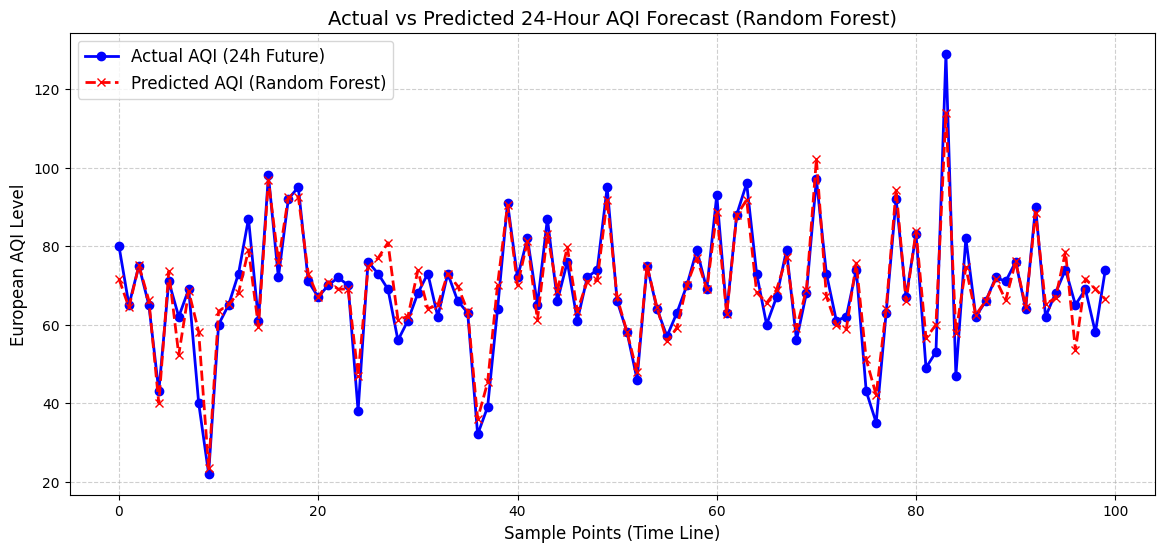

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
y_pred_final = best_model.predict(X_test)

plt.figure(figsize=(14, 6))

plt.plot(y_test.values[:100], label='Actual AQI (24h Future)', color='blue', linewidth=2, marker='o')
plt.plot(y_pred_final[:100], label=f'Predicted AQI ({best_model_name})', color='red', linestyle='--', linewidth=2, marker='x')

plt.title(f"Actual vs Predicted 24-Hour AQI Forecast ({best_model_name})", fontsize=14)
plt.xlabel("Sample Points (Time Line)", fontsize=12)
plt.ylabel("European AQI Level", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [16]:
import joblib
import os

os.makedirs("models", exist_ok=True)

rf_forecaster = trained_models["Random Forest"]
model_save_path = "models/random_forest_24hrsaqi_forecaster.pkl"

joblib.dump(rf_forecaster, model_save_path)

print(f"Model has been saved successfully {model_save_path}")

Model has been saved successfully models/random_forest_24hrsaqi_forecaster.pkl
